In [1]:
import importlib
import cross_sectional_estimation_v1 as cse
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
from plot_style import apply
apply()
importlib.reload(cse)

c:\Users\jonat\anaconda3\envs\jupyter311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_sectional_estimation_v1' from 'c:\\Users\\jonat\\Lasso_paper\\Empirical\\estimation\\cross_sectional_estimation_v1.py'>

In [12]:
OUT_DIR = 'results_v1'

# ── Load tensor and coordinates ──────────────────────────────────────────────
with h5py.File(os.path.join(OUT_DIR, 'betas.h5'), 'r') as f:
    betas  = f['betas'][:]               # (n_stocks, n_topics, n_dates) float32
    stocks = f['stocks'][:].astype(str)
    topics = f['topics'][:].astype(str)
    dates  = pd.to_datetime(f['dates'][:].astype(str))

summary_df = pd.read_csv(os.path.join(OUT_DIR, 'summary.csv'), index_col=0)
summary_df.index = summary_df.index.astype(str)

# ── Derived quantities ───────────────────────────────────────────────────────
# NaN entries mean the stock had no data at that date; treat as not selected
betas_nz = np.nan_to_num(betas, nan=0.0)
sel      = betas_nz != 0                 # (n_stocks, n_topics, n_dates) bool

has_data     = np.isfinite(betas).any(axis=1)                      # (n_stocks, n_dates)
n_valid_days = has_data.sum(axis=1, keepdims=True).astype(float)   # (n_stocks, 1)

# Selection frequency per (stock, topic): fraction of valid days topic was selected
sel_mat = sel.sum(axis=2) / np.maximum(n_valid_days, 1)  # (n_stocks, n_topics)

# Active topics per (stock, date) — NaN where stock has no data
active_per_day = sel.sum(axis=1).astype(float)   # (n_stocks, n_dates)
active_per_day[~has_data] = np.nan

# Per-stock mean active topics over time
mean_num_active = np.nanmean(active_per_day, axis=1)  # (n_stocks,)
summary_df['mean_num_active'] = pd.Series(mean_num_active, index=stocks)

# Per-topic average selection frequency across all stocks
topic_avg_series = (
    pd.Series(sel_mat.mean(axis=0), index=topics)
    .sort_values(ascending=False)
)

# Filtered selection matrix: only non-failed stocks (at least one selection)
valid_mask = mean_num_active > 0
sel_mat_df = pd.DataFrame(sel_mat[valid_mask], index=stocks[valid_mask], columns=topics)
mean_sel   = sel_mat_df.mean()   # per-topic avg across non-failed stocks

print(f'Tensor  : {betas.shape}')
print(f'Stocks  : {len(stocks)}  ({valid_mask.sum()} non-failed)')
print(f'Topics  : {len(topics)}')
print(f'Dates   : {len(dates)}  ({dates[0].date()} \u2192 {dates[-1].date()})')
summary_df.head()

Tensor  : (1620, 180, 1869)
Stocks  : 1620  (690 non-failed)
Topics  : 180
Dates   : 1869  (2010-02-02 → 2017-06-30)


C:\Users\jonat\AppData\Local\Temp\ipykernel_50168\1028408300.py:29: RuntimeWarning: Mean of empty slice
  mean_num_active = np.nanmean(active_per_day, axis=1)  # (n_stocks,)


,window_size,n_lags,lambda,r2_insample_stage1,r2_oos_stage1,r2_insample_stage2,r2_oos_stage2,kappa,kappa_tstat,intercept,intercept_tstat,n_observations,n_windows,n_oos_predictions_stage2,return_variance,failed,mean_num_active
stock,,,,,,,,,,,,,,,,,
10065,20,1,5.783056e-07,0.943195,-0.609926,-2.921805e-08,-0.001290,3.034142e-07,0.000013,0.000474,2.237081,1863,1866,NaN,0.000084,True,NaN
10145,20,1,5.783056e-07,0.961738,-0.515328,2.179869e-04,-0.004537,1.458323e-02,0.645877,0.000769,2.480232,1863,1866,NaN,0.000181,NaN,47.858748
10294,20,1,5.783056e-07,0.953382,-0.555359,-1.797499e-08,-0.000197,1.883621e-07,0.000008,0.000470,0.873211,1863,1866,NaN,0.000537,True,NaN
10375,20,1,5.783056e-07,0.952534,-0.599456,8.026121e-05,-0.001240,8.788011e-03,0.389851,0.000139,0.315027,1863,1866,NaN,0.000361,NaN,55.737293
10516,20,1,5.783056e-07,0.946194,-0.464958,7.766975e-05,-0.013955,9.198669e-03,0.383963,0.000260,0.721706,1863,1866,NaN,0.000242,NaN,51.704655


In [2]:
import numpy as np
import pandas as pd
import h5py
from scipy.spatial.distance import pdist, squareform

# --- Load tensor (shape must be: stocks x topics x dates) ---
h5_path = r"C:\Users\jonat\Lasso_paper\Empirical\estimation\results_v1\betas.h5"
with h5py.File(h5_path, "r") as f:
    beta = f["betas"][:]                       # (n_stocks, n_topics, n_dates)
    stocks = f["stocks"][:].astype(str)
    topics = f["topics"][:].astype(str)
    dates = pd.to_datetime(f["dates"][:].astype(str))

print("beta shape:", beta.shape)

# Binary selection indicator: 1 if topic selected (non-zero), else 0.
# Treat NaN as not selected.
selected = np.isfinite(beta) & (beta != 0)

n_stocks, n_topics, n_dates = selected.shape

# =========================================================
# 1) "Is topic k on day t selected only by one stock or many?"
#    -> Selection breadth across stocks for each (topic, day)
# =========================================================
breadth_counts = selected.sum(axis=0)               # shape: (n_topics, n_dates)
breadth_share = breadth_counts / 690           # fraction of stocks selecting topic k at date t

# Long table for inspection / filtering
breadth_df = (
    pd.DataFrame(
        {
            "topic": np.repeat(topics, n_dates),
            "date": np.tile(dates, n_topics),
            "n_selected_stocks": breadth_counts.reshape(-1),
            "share_selected_stocks": breadth_share.reshape(-1),
        }
    )
    .sort_values(["share_selected_stocks", "n_selected_stocks"], ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 most broadly selected (topic, date) pairs:")
print(breadth_df.head(100))

# # Optional: specific question "topic1 at day1"
# topic1 = topics[0]
# day1 = dates[0]
# i_topic = np.where(topics == topic1)[0][0]
# i_day = np.where(dates == day1)[0][0]
# print(f"\nExample -> {topic1} on {day1.date()}: "
#       f"{breadth_counts[i_topic, i_day]} stocks "
#       f"({breadth_share[i_topic, i_day]:.2%})")

# # =========================================================
# # 2) Similarity of selection patterns between stocks
# #    Compare binary vectors over all (topic, date) pairs
# # =========================================================
# X = selected.reshape(n_stocks, n_topics * n_dates).astype(np.uint8)

# # Jaccard similarity: overlap in selected topic-day pairs (best for sparse binary data)
# jaccard_dist = pdist(X, metric="jaccard")
# jaccard_sim = 1.0 - squareform(jaccard_dist)
# np.fill_diagonal(jaccard_sim, 1.0)

# sim_df = pd.DataFrame(jaccard_sim, index=stocks, columns=stocks)

# # Long table of stock pairs
# pairs = []
# for i in range(n_stocks):
#     for j in range(i + 1, n_stocks):
#         pairs.append((stocks[i], stocks[j], jaccard_sim[i, j]))
# pairs_df = pd.DataFrame(pairs, columns=["stock_i", "stock_j", "jaccard_similarity"])
# pairs_df = pairs_df.sort_values("jaccard_similarity", ascending=False).reset_index(drop=True)

# print("\nTop 20 most similar stock pairs (Jaccard):")
# print(pairs_df.head(20))


beta shape: (1620, 180, 1869)

Top 20 most broadly selected (topic, date) pairs:
            topic       date  n_selected_stocks  share_selected_stocks
0        Research 2011-08-09                683               0.989855
1    Police/crime 2011-08-12                680               0.985507
2     Bond_yields 2011-08-08                679               0.984058
3     Short_sales 2011-08-08                679               0.984058
4   Announce_plan 2011-08-09                678               0.982609
..            ...        ...                ...                    ...
95       Internet 2011-10-10                648               0.939130
96   Police/crime 2011-09-02                648               0.939130
97      Recession 2011-08-09                648               0.939130
98     Regulation 2011-08-29                648               0.939130
99     Regulation 2011-09-02                648               0.939130

[100 rows x 4 columns]


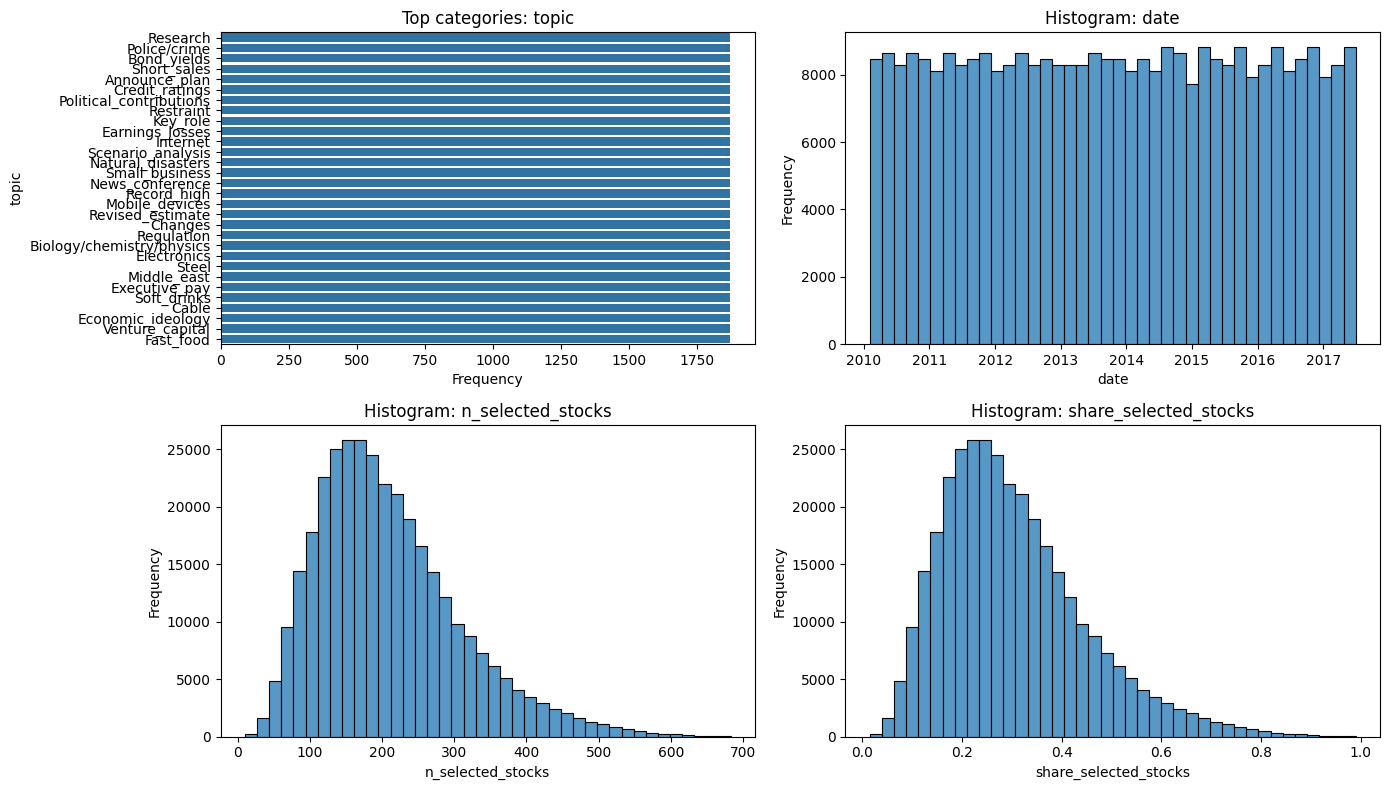

In [5]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# breadth_df expected columns: topic, date, n_selected_stocks, share_selected_stocks
df = breadth_df.copy()

# Ensure datetime
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

cols = df.columns.tolist()
n = len(cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, c in enumerate(cols):
    ax = axes[i]

    if pd.api.types.is_numeric_dtype(df[c]):
        # Frequency histogram for numeric columns
        sns.histplot(df[c].dropna(), bins=40, edgecolor="black", ax=ax)
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.set_title(f"Histogram: {c}")

    elif pd.api.types.is_datetime64_any_dtype(df[c]):
        # Date-frequency histogram
        sns.histplot(df[c].dropna(), bins=40, edgecolor="black", ax=ax)
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.set_title(f"Histogram: {c}")

    else:
        # For categorical columns, "frequency histogram" via value counts bar chart (top 30)
        vc = df[c].value_counts().head(30)
        sns.barplot(x=vc.values, y=vc.index, orient="h", ax=ax)
        ax.set_xlabel("Frequency")
        ax.set_ylabel(c)
        ax.set_title(f"Top categories: {c}")

# Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


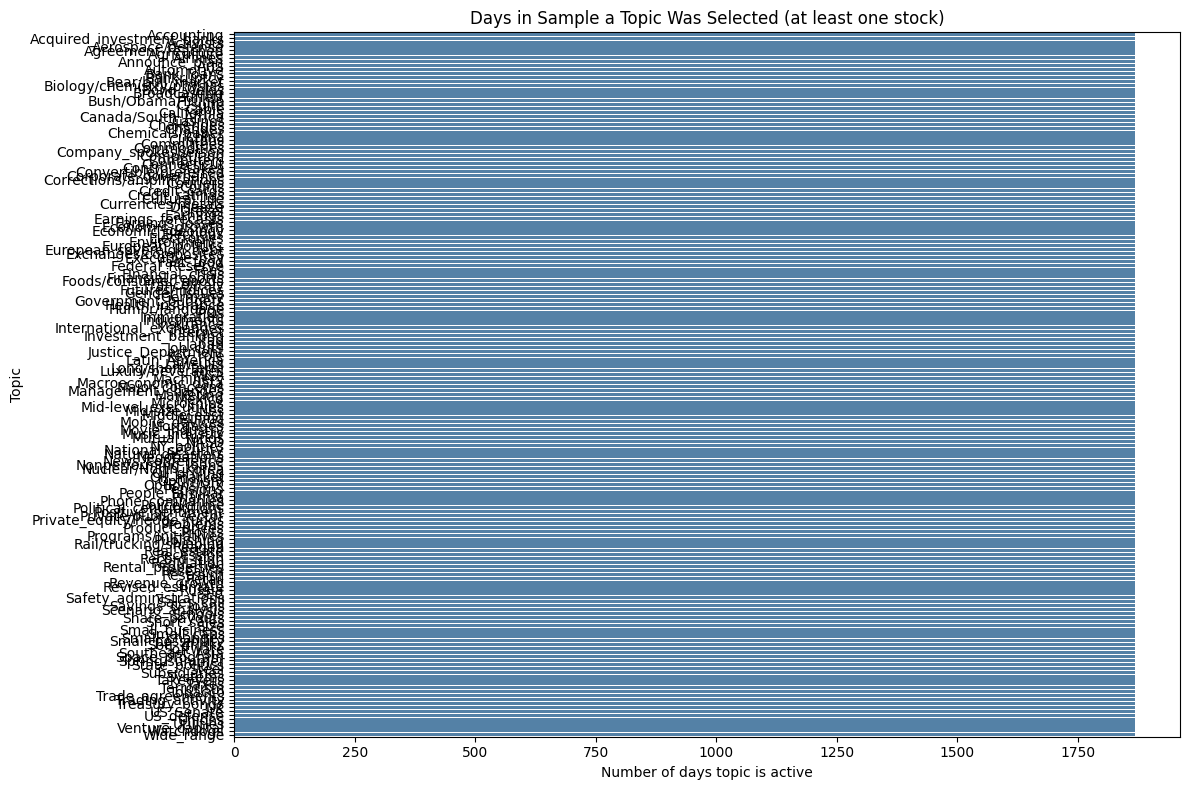

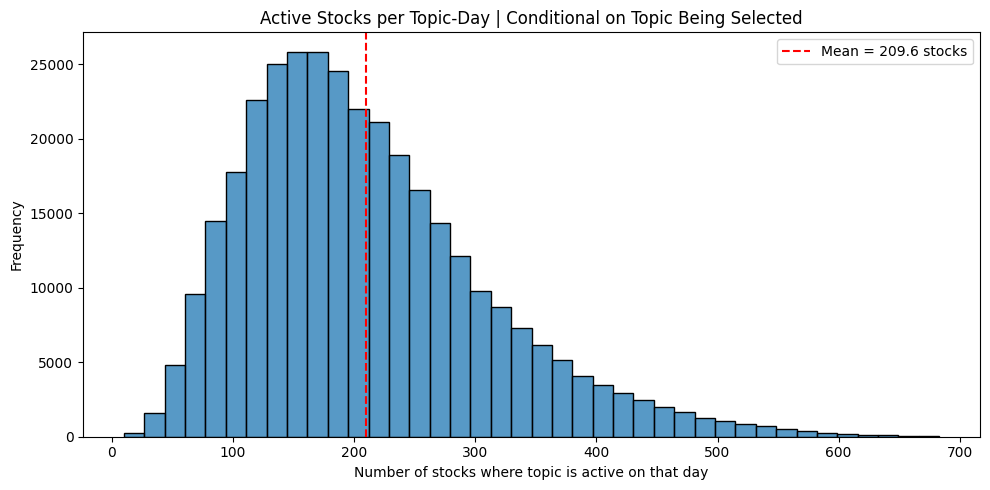

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# beta shape assumed: (n_stocks, n_topics, n_dates)
selected = np.isfinite(beta) & (beta != 0)
n_stocks, n_topics, n_dates = selected.shape

# topic x date: number of active stocks
breadth_counts = selected.sum(axis=0)  # shape: (n_topics, n_dates)

# -----------------------------
# Plot 1: For each topic, on how many days was it selected for at least 1 stock?
# -----------------------------
days_selected_per_topic = (breadth_counts > 0).sum(axis=1)  # length n_topics

topic_days_df = pd.DataFrame({
    "topic": topics,
    "days_selected": days_selected_per_topic
}).sort_values("days_selected", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=topic_days_df, x="days_selected", y="topic", color="steelblue")
plt.title("Days in Sample a Topic Was Selected (at least one stock)")
plt.xlabel("Number of days topic is active")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Conditional on topic being selected, for how many stocks is it active on a day?
# -----------------------------
active_stock_counts_cond = breadth_counts[breadth_counts > 0].ravel()

plt.figure(figsize=(10, 5))
sns.histplot(active_stock_counts_cond, bins=40, edgecolor="black")
plt.axvline(active_stock_counts_cond.mean(), color="red", linestyle="--",
            label=f"Mean = {active_stock_counts_cond.mean():.1f} stocks")
plt.title("Active Stocks per Topic-Day | Conditional on Topic Being Selected")
plt.xlabel("Number of stocks where topic is active on that day")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
